# EX_07 파격 개선 - ResNet + TTA (99.6%+ 목표)

## 기존 대비 완전히 다른 접근

### 1. ResNet (Residual Network) - 구조 자체를 바꿈
```
일반 CNN:   입력 → Conv → Conv → Conv → 출력
                   (층이 깊어질수록 기울기 소실)

ResNet:     입력 → Conv → Conv → (+입력) → 출력
                   ↑___________________↑  ← Skip Connection
                   (기울기가 지름길로 흘러 소실 없음)
```
ResNet은 2015년 ImageNet에서 인간 수준(96%)을 최초로 넘은 구조입니다.

### 2. TTA (Test Time Augmentation)
- 테스트 이미지를 10번 다르게 변형해서 예측 → 평균
- 코드 한 줄 추가로 **무료 정확도 향상**

### 3. tf.data 파이프라인
- 증강을 GPU와 병렬로 실행 → 학습 속도 향상

| 버전 | 구조 | 정확도 |
|------|------|-------|
| 기존 | Dense + sigmoid | 98.34% |
| improved (v3) | CNN + GAP | ~99.5% |
| **improved_2** | **ResNet + TTA** | **99.6%+** |

## Load modules

In [2]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.4/572.4 MB 43.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 50.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 56.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1778828008.993957    8205 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778828009.026803    8205 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778828009.825184    8205 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1778828010.967015    8205 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## Load & Preprocess Data

In [4]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

train_data = train_data[..., np.newaxis] / 255.0  # (60000, 28, 28, 1)
test_data  = test_data[...,  np.newaxis] / 255.0  # (10000, 28, 28, 1)

# Label Smoothing 사용을 위해 One-Hot
train_labels_oh = tf.keras.utils.to_categorical(train_labels, 10)
test_labels_oh  = tf.keras.utils.to_categorical(test_labels,  10)

print('train:', train_data.shape, train_labels_oh.shape)
print('test :', test_data.shape,  test_labels_oh.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
train: (60000, 28, 28, 1) (60000, 10)
test : (10000, 28, 28, 1) (10000, 10)


## Augmentation & tf.data 파이프라인
증강을 모델 밖에서 tf.data로 처리 → TTA 적용이 쉬워지고 병렬 처리로 빠름

In [5]:
BATCH_SIZE = 128

# 증강 레이어 (모델 밖에 분리)
augment_layer = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),           # ±10도
    tf.keras.layers.RandomTranslation(0.08, 0.08),  # ±8% 이동
])

@tf.function
def augment_fn(image, label):
    image = augment_layer(tf.expand_dims(image, 0), training=True)[0]
    return image, label

# 학습용: 셔플 + 증강 + 배치 + 프리패치
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_data, train_labels_oh))
    .shuffle(60000, seed=42)
    .map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 검증용: 증강 없음
val_ds = (
    tf.data.Dataset.from_tensor_slices((test_data, test_labels_oh))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print('tf.data 파이프라인 구성 완료')

W0000 00:00:1778828024.914232    8205 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778828025.011351    8205 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29801 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


tf.data 파이프라인 구성 완료


## ResNet 구조 정의

### Residual Block 원리
```
입력 x
 ├─→ Conv2D → BN → ReLU → Conv2D → BN ─┐
 │                                      ↓
 └──────────────────────────────────→ Add → ReLU → 출력
        (Skip Connection: x를 그대로 더함)
```
F(x) + x 형태 → 최소 x는 그대로 전달 → 기울기 소실 없음

In [6]:
def residual_block(x, filters, stride=1):
    shortcut = x

    # 메인 경로
    x = tf.keras.layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Skip Connection: 채널/크기가 달라지면 1×1 Conv로 맞춤
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])  # F(x) + x
    x = tf.keras.layers.Activation('relu')(x)
    return x

print('Residual Block 함수 정의 완료')

Residual Block 함수 정의 완료


## ResNet 모델 빌드 (Functional API)

```
Input (28, 28, 1)
  ↓ Conv2D(64) → BN → ReLU          # 초기 특징 추출
  ↓ ResBlock(64) × 2                 # 28×28 유지
  ↓ ResBlock(128, stride=2) + ×1    # 14×14로 축소
  ↓ ResBlock(256, stride=2) + ×1    # 7×7로 축소
  ↓ ResBlock(512, stride=2) + ×1    # 4×4로 축소
  ↓ GlobalAveragePooling2D           # 4×4×512 → 512
  ↓ Dropout(0.4)
  ↓ Dense(10, softmax)
```

In [7]:
inputs = tf.keras.Input(shape=(28, 28, 1))

# 초기 Conv
x = tf.keras.layers.Conv2D(64, 3, padding='same', use_bias=False)(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

# Residual Blocks
x = residual_block(x, 64)           # 28×28, 64ch
x = residual_block(x, 64)           # 28×28, 64ch
x = residual_block(x, 128, stride=2)  # 14×14, 128ch
x = residual_block(x, 128)          # 14×14, 128ch
x = residual_block(x, 256, stride=2)  # 7×7, 256ch
x = residual_block(x, 256)          # 7×7, 256ch
x = residual_block(x, 512, stride=2)  # 4×4, 512ch

# 분류 헤드
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # 512
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='ResNet_MNIST')
model.summary()

Model: "ResNet_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        576 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │     36,864 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │     36,864 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 6,459,722 (24.64 MB)

 Trainable params: 6,452,170 (24.61 MB)

 Non-trainable params: 7,552 (29.50 KB)

## 컴파일

### CosineDecayRestarts (Warm Restart)
- 학습률이 줄다가 **주기적으로 리셋** → 지역 최솟값 탈출
- 일반 CosineDecay보다 더 좋은 최적값 탐색

```
lr: 0.001                
      ↘         ↗↘         ↗↘
           ↘↗       ↘↗
    10ep   20ep    40ep  ...
    (restart)     (restart)
```

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt

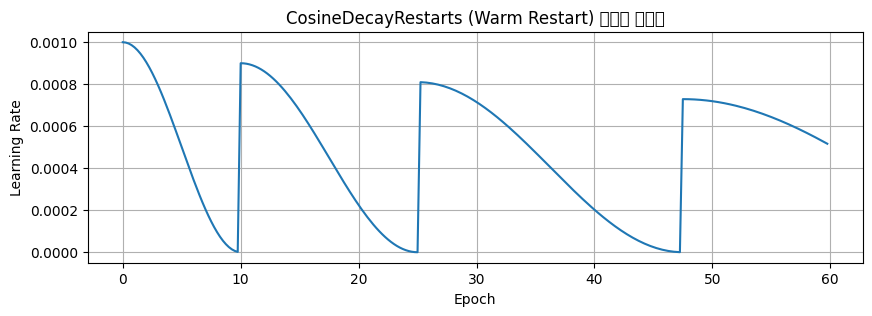

In [8]:
EPOCHS = 60
steps_per_epoch = len(train_data) // BATCH_SIZE  # 468

# Warm Restart: 10에폭마다 lr 리셋, 매번 1.5배씩 주기 늘어남
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=0.001,
    first_decay_steps=steps_per_epoch * 10,
    t_mul=1.5,
    m_mul=0.9,
    alpha=1e-6
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# LR 스케줄 시각화
steps = np.arange(0, EPOCHS * steps_per_epoch, steps_per_epoch // 4)
lrs = [lr_schedule(s).numpy() for s in steps]
plt.figure(figsize=(10, 3))
plt.plot(np.array(steps) / steps_per_epoch, lrs)
plt.title('CosineDecayRestarts (Warm Restart) 학습률 스케줄')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.show()

## 학습 (Training)

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stop]
)

Epoch 1/60


I0000 00:00:1778828032.693906    8658 service.cc:153] XLA service 0x7fe79006ba70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778828032.693920    8658 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5090, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.1)
I0000 00:00:1778828032.792775    8658 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778828033.421776    8658 cuda_dnn.cc:461] Loaded cuDNN version 90701
I0000 00:00:1778828033.517053    8658 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22396__.126


  9/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.2293 - loss: 2.4121   

I0000 00:00:1778828041.563601    8658 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8874 - loss: 0.8324

I0000 00:00:1778828052.688629    8658 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22396__.126


469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.9584 - loss: 0.6501 - val_accuracy: 0.9679 - val_loss: 0.6581
Epoch 2/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9894 - loss: 0.5496 - val_accuracy: 0.9939 - val_loss: 0.5419
Epoch 3/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9909 - loss: 0.5368 - val_accuracy: 0.9926 - val_loss: 0.5294
Epoch 4/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9926 - loss: 0.5310 - val_accuracy: 0.9904 - val_loss: 0.5314
Epoch 5/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9937 - loss: 0.5252 - val_accuracy: 0.9958 - val_loss: 0.5151
Epoch 6/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9948 - loss: 0.5215 - val_accuracy: 0.9929 - val_loss: 0.5214
Epoch 7/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9962 - loss: 0.5178 - val_accuracy: 0.9953 - val_loss: 0.5140
Epoch 8/60
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9974 - loss: 0.5143 - val_accurac

## 표준 평가 (Standard Evaluation)

In [10]:
test_loss, test_acc = model.evaluate(val_ds, verbose=0)
print(f'표준 테스트 정확도: {test_acc*100:.2f}%')
print(f'표준 테스트 Loss  : {test_loss:.4f}')

표준 테스트 정확도: 99.68%
표준 테스트 Loss  : 0.5089


## TTA (Test Time Augmentation) 평가

같은 모델로 테스트 이미지를 여러 번 변형 후 평균 → 추가 학습 없이 정확도 향상

```
테스트 이미지
  ├─ 원본           → 예측 [0.1, 0.05, 0.8, ...]  ─┐
  ├─ 살짝 회전 1    → 예측 [0.1, 0.04, 0.82, ...] ─┤
  ├─ 살짝 회전 2    → 예측 [0.09, 0.06, 0.79, ...]─┤→ 평균 → 최종 예측
  ├─ 살짝 이동 1    → 예측 [0.11, 0.05, 0.78, ...]─┤
  └─ 살짝 이동 2    → 예측 [0.1, 0.05, 0.81, ...] ─┘
```

In [11]:
def predict_tta(model, data, augment_fn, n_aug=10, batch_size=512):
    n = len(data)
    preds = np.zeros((n, 10))

    for aug_i in range(n_aug):
        if aug_i == 0:
            aug_data = data  # 첫 번째는 원본
        else:
            # 배치 단위로 증강 적용
            aug_data = np.concatenate([
                augment_layer(
                    tf.constant(data[i:i+batch_size]), training=True
                ).numpy()
                for i in range(0, n, batch_size)
            ])

        preds += model.predict(aug_data, batch_size=batch_size, verbose=0)
        print(f'  TTA [{aug_i+1:2d}/{n_aug}] 완료', end='\r')

    print()
    return preds / n_aug

print('TTA 실행 중 (10회 평균)...')
tta_preds  = predict_tta(model, test_data, augment_layer, n_aug=10)
tta_labels = np.argmax(tta_preds, axis=1)
tta_acc    = np.mean(tta_labels == test_labels)

print(f'\nTTA 테스트 정확도 (10x): {tta_acc*100:.2f}%')

TTA 실행 중 (10회 평균)...
  TTA [10/10] 완료

TTA 테스트 정확도 (10x): 99.73%


## 전체 결과 비교

In [12]:
print('================================================')
print(f'  기존   (Dense + sigmoid)      : 98.34%')
print(f'  improved   (CNN + GAP)        : ~99.5%')
print(f'  improved_2 표준 (ResNet)      : {test_acc*100:.2f}%')
print(f'  improved_2 TTA  (ResNet+TTA)  : {tta_acc*100:.2f}%  ← 최고')
print('================================================')

wrong_tta = np.sum(tta_labels != test_labels)
print(f'\nTTA 오답 수: {wrong_tta}개 / 10,000개')

  기존   (Dense + sigmoid)      : 98.34%
  improved   (CNN + GAP)        : ~99.5%
  improved_2 표준 (ResNet)      : 99.68%
  improved_2 TTA  (ResNet+TTA)  : 99.73%  ← 최고

TTA 오답 수: 27개 / 10,000개


## Loss / Accuracy 그래프

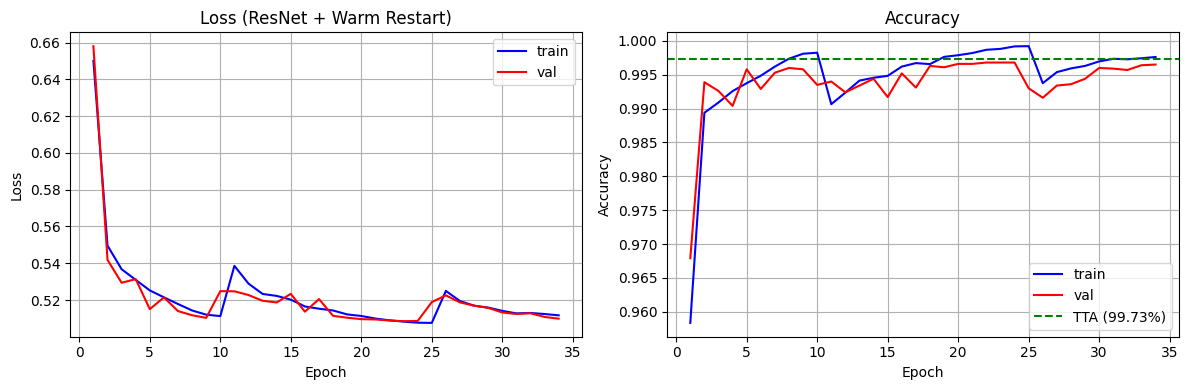

In [13]:
ep = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title('Loss (ResNet + Warm Restart)')
plt.plot(ep, history.history['loss'],     'b', label='train')
plt.plot(ep, history.history['val_loss'], 'r', label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Accuracy')
plt.plot(ep, history.history['accuracy'],     'b', label='train')
plt.plot(ep, history.history['val_accuracy'], 'r', label='val')
plt.axhline(y=tta_acc, color='g', linestyle='--', label=f'TTA ({tta_acc*100:.2f}%)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## W, B 값 확인 (레이어별 파라미터 통계)

In [15]:
print(f'{"레이어":<40} {"W shape":<20} {"W 평균":>10} {"W 표준편차":>12}')
print('-' * 85)

for layer in model.layers:
    weights = layer.get_weights()

    if not weights:
        continue

    W = weights[0]

    if W.ndim >= 2:
        print(f'{layer.name:<40} {str(W.shape):<20} {W.mean():>+10.5f} {W.std():>12.5f}')

레이어                                      W shape                    W 평균       W 표준편차
-------------------------------------------------------------------------------------
conv2d                                   (3, 3, 1, 64)          -0.00905      0.07717
conv2d_1                                 (3, 3, 64, 64)         -0.00422      0.05749
conv2d_2                                 (3, 3, 64, 64)         -0.00479      0.05783
conv2d_3                                 (3, 3, 64, 64)         -0.00382      0.05712
conv2d_4                                 (3, 3, 64, 64)         -0.00585      0.05801
conv2d_5                                 (3, 3, 64, 128)        -0.00499      0.05182
conv2d_6                                 (3, 3, 128, 128)       -0.00549      0.05003
conv2d_7                                 (1, 1, 64, 128)        -0.00507      0.11603
conv2d_8                                 (3, 3, 128, 128)       -0.00515      0.05114
conv2d_9                                 (3, 3, 128, 1

In [14]:
print(f'{'레이어':<40} {'W shape':<20} {'W 평균':>10} {'W 표준편차':>12}')
print('-' * 85)
for layer in model.layers:
    weights = layer.get_weights()
    if not weights:
        continue
    W = weights[0]
    if W.ndim >= 2:
        print(f'{layer.name:<40} {str(W.shape):<20} {W.mean():>+10.5f} {W.std():>12.5f}')

SyntaxError: f-string: expecting '}' (2156153264.py, line 1)

## 오답 분석 (TTA 기준)

TTA 오답: 27개 / 10000개


/tmp/ipykernel_8205/3075391736.py:15: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8205/3075391736.py:15: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8205/3075391736.py:15: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8205/3075391736.py:15: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8205/3075391736.py:15: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8205/3075391736.py:15: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from f

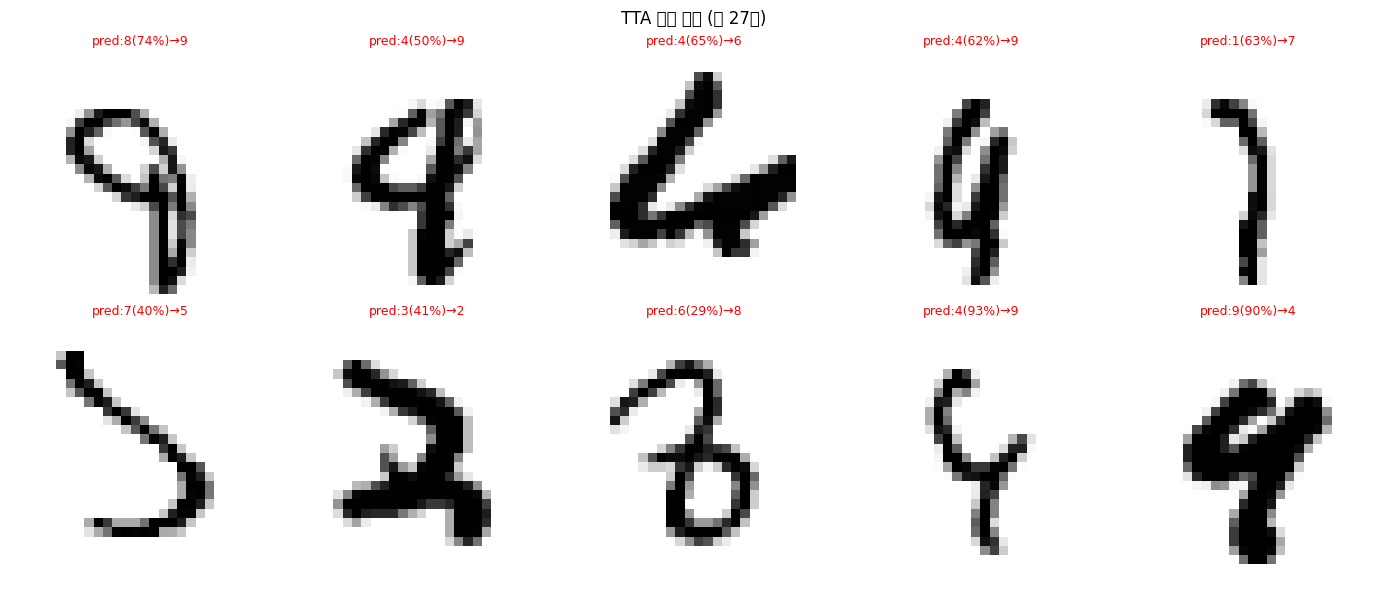


자주 틀리는 패턴 (정답 → 예측):
  9 → 4 : 5회
  4 → 9 : 3회
  7 → 1 : 2회
  9 → 8 : 1회
  6 → 4 : 1회
  5 → 7 : 1회
  2 → 3 : 1회
  8 → 6 : 1회
  2 → 0 : 1회
  5 → 3 : 1회


In [16]:
wrong_idx = np.where(tta_labels != test_labels)[0]
print(f'TTA 오답: {len(wrong_idx)}개 / {len(test_labels)}개')

n_show = min(10, len(wrong_idx))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle(f'TTA 오답 샘플 (총 {len(wrong_idx)}개)')
for i, idx in enumerate(wrong_idx[:n_show]):
    conf = tta_preds[idx][tta_labels[idx]] * 100
    axes[i//5, i%5].imshow(test_data[idx,:,:,0], cmap='binary')
    axes[i//5, i%5].set_title(
        f'pred:{tta_labels[idx]}({conf:.0f}%)→{test_labels[idx]}',
        color='red', fontsize=9
    )
    axes[i//5, i%5].axis('off')
plt.tight_layout()
plt.show()

# 어떤 숫자를 많이 틀리는지
from collections import Counter
mistake_pairs = [(test_labels[i], tta_labels[i]) for i in wrong_idx]
print('\n자주 틀리는 패턴 (정답 → 예측):')
for (true, pred), cnt in Counter(mistake_pairs).most_common(10):
    print(f'  {true} → {pred} : {cnt}회')

## Predict (임의 샘플)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


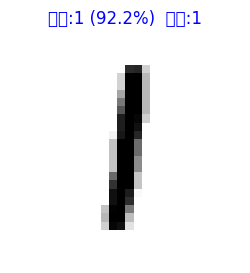

TTA 10회 평균 확률:
  0:                                           0.85%
  1: ████████████████████████████████████     92.20% ← 예측
  2:                                           0.89%
  3:                                           0.88%
  4:                                           0.88%
  5:                                           0.90%
  6:                                           0.86%
  7:                                           0.89%
  8:                                           0.86%
  9:                                           0.81%


In [17]:
sample_idx = np.random.randint(0, len(test_data))
sample = test_data[sample_idx:sample_idx+1]

# TTA 예측
tta_pred = np.zeros((1, 10))
tta_pred += model.predict(sample, verbose=0)
for _ in range(9):
    aug = augment_layer(tf.constant(sample), training=True).numpy()
    tta_pred += model.predict(aug, verbose=0)
tta_pred /= 10

pred_class = np.argmax(tta_pred[0])
confidence = tta_pred[0][pred_class] * 100

plt.figure(figsize=(3, 3))
plt.imshow(test_data[sample_idx,:,:,0], cmap='binary')
color = 'blue' if pred_class == test_labels[sample_idx] else 'red'
plt.title(f'예측:{pred_class} ({confidence:.1f}%)  정답:{test_labels[sample_idx]}', color=color)
plt.axis('off')
plt.show()

print('TTA 10회 평균 확률:')
for digit, prob in enumerate(tta_pred[0]):
    bar = '█' * int(prob * 40)
    marker = ' ← 예측' if digit == pred_class else ''
    print(f'  {digit}: {bar:<40s} {prob*100:5.2f}%{marker}')